# A year of road collisions in Britain, in plain SQL

Every injury collision reported to the police in Great Britain in 2023: **104,258 collisions, 189,815 vehicles and 132,977 casualties** in three linked tables. Eight questions in SQL only: joins across all three tables with lookup labels, severity rates with conditional aggregation, hour-by-weekday patterns, risk by speed limit, light and vehicle type, and age bands built with `CASE` and window shares. Python only runs the queries and draws the charts.

**Data:** [Road safety data](https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-safety-data) (STATS19) from the Department for Transport, published under the Open Government Licence. Run `python build_db.py` once to download the three CSV files (about 52 MB) into a SQLite database, then point `ROADS_DB` at that file.

**Reading the data.** Only collisions in which someone was injured and the police were told are included. "Fatal or serious" means the worst injury in the collision. The files hold numeric codes, and the labels here are mapped from the DfT guide; vehicle types whose code is not certain are shown as unclassified. Counts show where collisions happened, not how risky a road is per mile or per journey, because there is no traffic volume in the data.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("ROADS_DB", "roads.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,areas,3
1,casualties,132977
2,casualty_classes,3
3,collisions,104258
4,light,5
5,severities,3
6,vehicle_types,20
7,vehicles,189815
8,weather,9
9,weekdays,7


## 1. How serious are the collisions?

A join to the severity lookup and `SUM(COUNT(*)) OVER ()` for the share of each severity.

In [3]:
severity = q("""
SELECT s.severity_name                                   AS severity,
       COUNT(*)                                          AS collisions,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
       SUM(c.number_of_casualties)                       AS casualties,
       ROUND(AVG(c.number_of_vehicles), 2)               AS avg_vehicles,
       ROUND(AVG(c.number_of_casualties), 2)             AS avg_casualties
FROM collisions c
JOIN severities s ON s.severity = c.collision_severity
GROUP BY c.collision_severity
ORDER BY c.collision_severity
""")

severity

,severity,collisions,share_pct,casualties,avg_vehicles,avg_casualties
0,Fatal,1522,1.5,2661,1.75,1.75
1,Serious,23438,22.5,31976,1.73,1.36
2,Slight,79298,76.1,98340,1.85,1.24


## 2. When do collisions happen?

Dates are stored as text, so `strftime('%H', time)` and the day-of-week code give the hour and weekday of every collision. Commuting hours light up the heatmap.

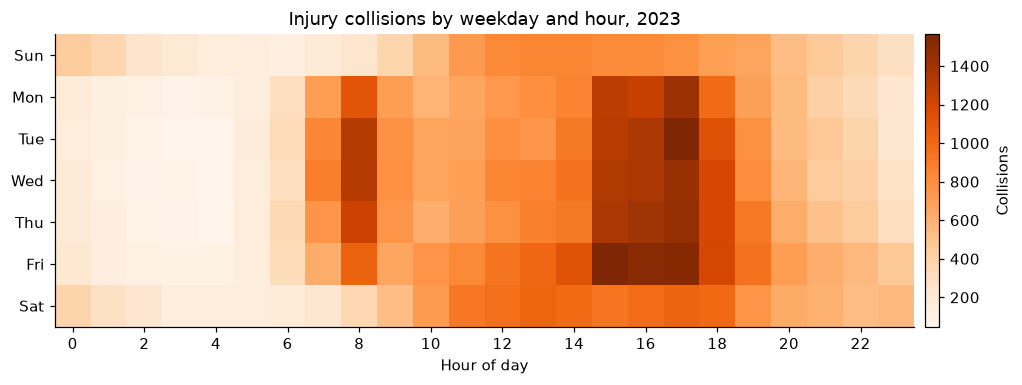

In [4]:
when = q("""
SELECT c.day_of_week,
       w.weekday_name                                 AS weekday,
       CAST(substr(c.time, 1, 2) AS INT)              AS hour,
       COUNT(*)                                       AS collisions
FROM collisions c
JOIN weekdays w USING (day_of_week)
GROUP BY c.day_of_week, hour
ORDER BY c.day_of_week, hour
""")

grid = when.pivot(index="day_of_week", columns="hour", values="collisions").fillna(0)
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(grid.values, cmap="Oranges", aspect="auto")
ax.set_yticks(range(7), ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
ax.set_xticks(range(0, 24, 2), range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_title("Injury collisions by weekday and hour, 2023")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Collisions", pad=0.01)
fig.tight_layout()
plt.show()

## 3. Are the quiet hours safer?

Averaging a 0/1 `CASE` flag per hour gives the share of collisions that were fatal or serious. Few collisions happen at night, but the ones that do are more severe.

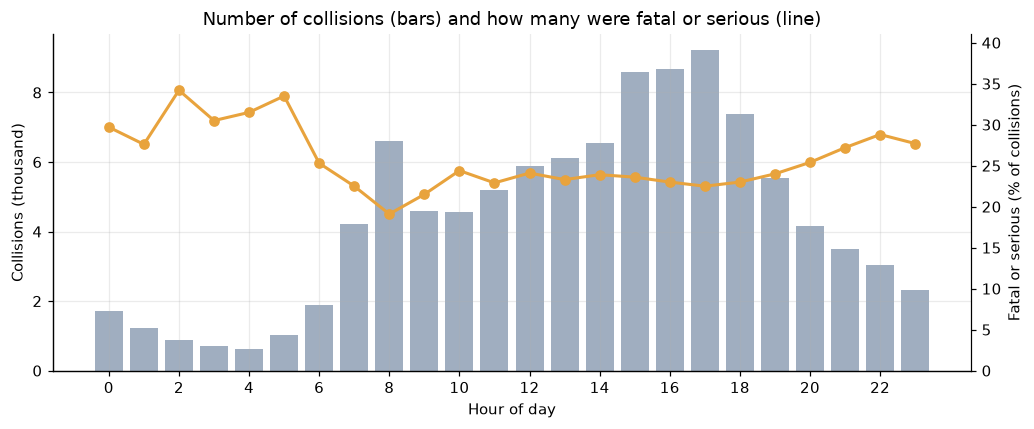

,hour,collisions,fatal_or_serious,fatal_or_serious_pct,fatal_pct
8,8,6598,1259,19.1,0.76
2,2,874,299,34.2,3.78


In [5]:
hourly = q("""
SELECT CAST(substr(time, 1, 2) AS INT)                       AS hour,
       COUNT(*)                                              AS collisions,
       SUM(collision_severity <= 2)                          AS fatal_or_serious,
       ROUND(100.0 * AVG(collision_severity <= 2), 1)        AS fatal_or_serious_pct,
       ROUND(100.0 * AVG(collision_severity = 1), 2)         AS fatal_pct
FROM collisions
GROUP BY hour
ORDER BY hour
""")

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(hourly.hour, hourly.collisions / 1000, color=GREY)
ax.set_ylabel("Collisions (thousand)")
ax.set_xlabel("Hour of day")
ax.set_xticks(range(0, 24, 2))
ax2 = ax.twinx()
ax2.plot(hourly.hour, hourly.fatal_or_serious_pct, color=AMBER, marker="o", lw=2)
ax2.set_ylabel("Fatal or serious (% of collisions)")
ax2.set_ylim(0, hourly.fatal_or_serious_pct.max() * 1.2)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Number of collisions (bars) and how many were fatal or serious (line)")
fig.tight_layout()
plt.show()
hourly.sort_values("fatal_or_serious_pct").iloc[[0, -1]]

## 4. How much does the speed limit matter?

Grouping by the speed limit of the road shows how the share of fatal and serious collisions climbs with the limit. This compares *collisions*, so it says how bad a crash is on such a road, not how likely one is.

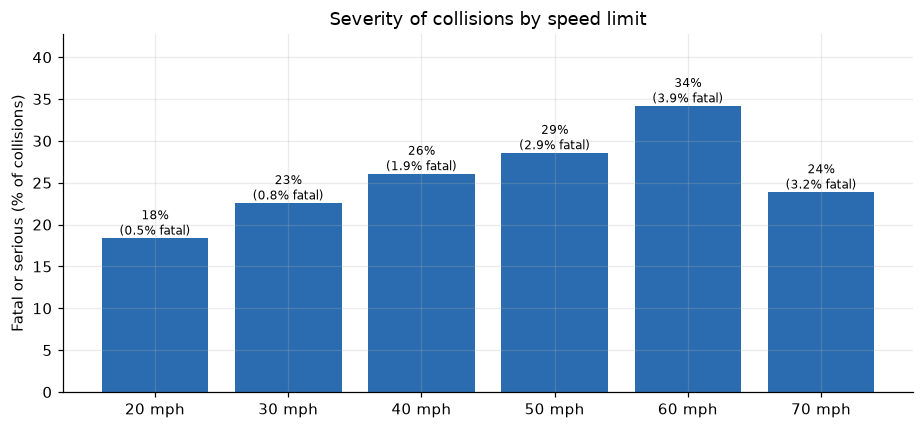

,speed_limit,collisions,fatal,fatal_or_serious_pct,fatal_pct,avg_casualties
0,20,17942,84,18.4,0.47,1.12
1,30,54177,457,22.6,0.84,1.22
2,40,9154,171,26.1,1.87,1.39
3,50,4593,135,28.6,2.94,1.47
4,60,12729,493,34.2,3.87,1.49
5,70,5663,182,23.9,3.21,1.53


In [6]:
speed = q("""
SELECT speed_limit,
       COUNT(*)                                       AS collisions,
       SUM(collision_severity = 1)                    AS fatal,
       ROUND(100.0 * AVG(collision_severity <= 2), 1) AS fatal_or_serious_pct,
       ROUND(100.0 * AVG(collision_severity = 1), 2)  AS fatal_pct,
       ROUND(AVG(number_of_casualties), 2)            AS avg_casualties
FROM collisions
GROUP BY speed_limit
ORDER BY speed_limit
""")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(speed.speed_limit.astype(str) + " mph", speed.fatal_or_serious_pct, color=BLUE)
for x, (v, f) in enumerate(zip(speed.fatal_or_serious_pct, speed.fatal_pct)):
    ax.text(x, v + 0.4, f"{v:.0f}%\n({f:.1f}% fatal)", ha="center", fontsize=8)
ax.set_ylim(0, speed.fatal_or_serious_pct.max() * 1.25)
ax.set_ylabel("Fatal or serious (% of collisions)")
ax.set_title("Severity of collisions by speed limit")
fig.tight_layout()
plt.show()
speed

## 5. Does darkness change the odds?

Lookup tables turn codes into names, and a `GROUP BY` over two dimensions (light conditions and urban or rural) compares severity inside each combination.

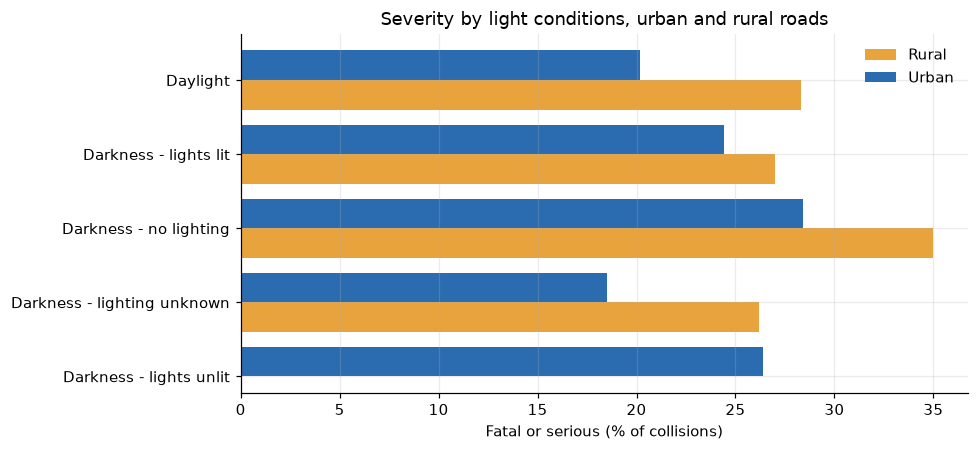

,light,area,collisions,fatal_or_serious_pct
0,Darkness - no lighting,Rural,5093,35.0
1,Daylight,Rural,24625,28.3
2,Darkness - lights lit,Rural,3512,27.0
3,Darkness - lighting unknown,Rural,450,26.2
4,Darkness - no lighting,Urban,535,28.4
5,Darkness - lights unlit,Urban,497,26.4
6,Darkness - lights lit,Urban,18487,24.4
7,Daylight,Urban,49609,20.2
8,Darkness - lighting unknown,Urban,1184,18.5


In [7]:
light = q("""
SELECT l.light_name                                     AS light,
       a.area_name                                      AS area,
       COUNT(*)                                         AS collisions,
       ROUND(100.0 * AVG(c.collision_severity <= 2), 1) AS fatal_or_serious_pct
FROM collisions c
JOIN light l USING (light_conditions)
JOIN areas a USING (urban_or_rural_area)
WHERE a.area_name IN ('Urban', 'Rural')
GROUP BY l.light_name, a.area_name
HAVING collisions >= 300
ORDER BY a.area_name, fatal_or_serious_pct DESC
""")

wide = light.pivot(index="light", columns="area", values="fatal_or_serious_pct").loc[
    light.groupby("light").collisions.sum().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(wide))
ax.barh(y + 0.2, wide["Rural"], height=0.4, color=AMBER, label="Rural")
ax.barh(y - 0.2, wide["Urban"], height=0.4, color=BLUE, label="Urban")
ax.set_yticks(y, wide.index)
ax.invert_yaxis()
ax.set_xlabel("Fatal or serious (% of collisions)")
ax.set_title("Severity by light conditions, urban and rural roads")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
light

## 6. Which vehicles are in the most dangerous collisions?

Vehicles are joined to their collision and to the vehicle-type lookup (a `LEFT JOIN`, so unclassified codes are kept as 'Unclassified'). The severity rate is for the **collisions each vehicle type was involved in**, which for a motorcycle or a bicycle is mostly the rider's own risk.

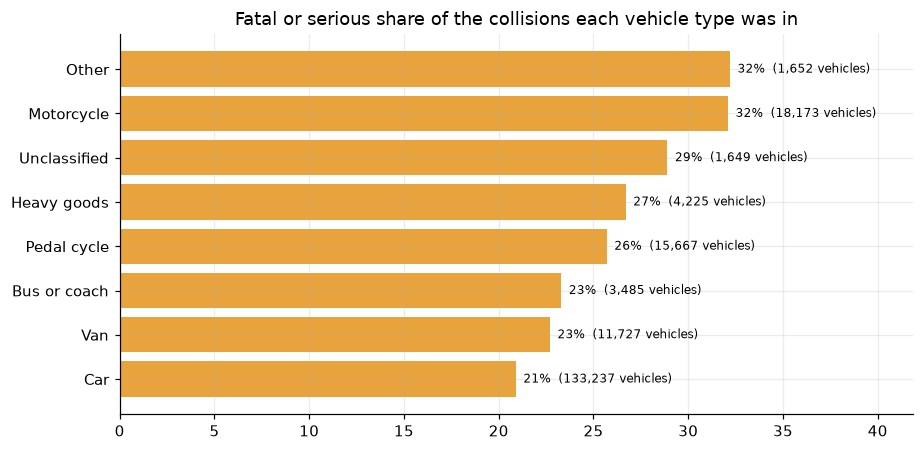

,vehicle_group,vehicles_involved,fatal_or_serious_pct,fatal_pct
0,Other,1652,32.2,3.21
1,Motorcycle,18173,32.1,1.96
2,Unclassified,1649,28.9,0.67
3,Heavy goods,4225,26.7,4.92
4,Pedal cycle,15667,25.7,0.61
5,Bus or coach,3485,23.3,1.64
6,Van,11727,22.7,1.65
7,Car,133237,20.9,1.27


In [8]:
vehicles = q("""
SELECT COALESCE(vt.vehicle_group, 'Unclassified')           AS vehicle_group,
       COUNT(*)                                             AS vehicles_involved,
       ROUND(100.0 * AVG(c.collision_severity <= 2), 1)     AS fatal_or_serious_pct,
       ROUND(100.0 * AVG(c.collision_severity = 1), 2)      AS fatal_pct
FROM vehicles v
JOIN collisions c USING (collision_index)
LEFT JOIN vehicle_types vt ON vt.vehicle_type = v.vehicle_type
GROUP BY vehicle_group
HAVING vehicles_involved >= 300
ORDER BY fatal_or_serious_pct DESC
""")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(vehicles.vehicle_group[::-1], vehicles.fatal_or_serious_pct[::-1], color=AMBER)
for y, (v, n) in enumerate(zip(vehicles.fatal_or_serious_pct[::-1], vehicles.vehicles_involved[::-1])):
    ax.text(v + 0.4, y, f"{v:.0f}%  ({n:,} vehicles)", va="center", fontsize=8)
ax.set_xlim(0, vehicles.fatal_or_serious_pct.max() * 1.3)
ax.set_title("Fatal or serious share of the collisions each vehicle type was in")
fig.tight_layout()
plt.show()
vehicles

## 7. Who gets hurt, by age?

A `CASE` builds age bands, a join brings in the casualty class (driver, passenger, pedestrian) and the collision record, and a window total gives each band's share of casualties. Casualties with an unknown age (about 2%) are left out.

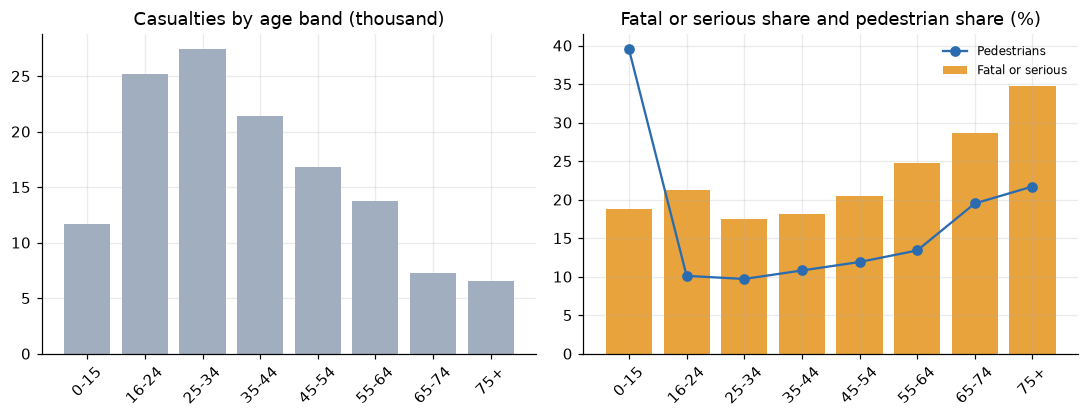

,age_band,casualties,share_pct,fatal_or_serious_pct,pedestrian_pct
0,0-15,11684,9.0,18.8,39.5
1,16-24,25173,19.4,21.3,10.1
2,25-34,27400,21.1,17.5,9.7
3,35-44,21402,16.5,18.1,10.8
4,45-54,16791,12.9,20.5,11.9
5,55-64,13789,10.6,24.7,13.4
6,65-74,7237,5.6,28.6,19.5
7,75+,6575,5.1,34.8,21.7


In [9]:
age = q("""
WITH banded AS (
    SELECT CASE WHEN k.age_of_casualty < 16 THEN '0-15'
                WHEN k.age_of_casualty < 25 THEN '16-24'
                WHEN k.age_of_casualty < 35 THEN '25-34'
                WHEN k.age_of_casualty < 45 THEN '35-44'
                WHEN k.age_of_casualty < 55 THEN '45-54'
                WHEN k.age_of_casualty < 65 THEN '55-64'
                WHEN k.age_of_casualty < 75 THEN '65-74'
                ELSE '75+' END                      AS age_band,
           k.casualty_severity, k.casualty_class
    FROM casualties k
    WHERE k.age_of_casualty >= 0
)
SELECT age_band,
       COUNT(*)                                             AS casualties,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)   AS share_pct,
       ROUND(100.0 * AVG(casualty_severity <= 2), 1)        AS fatal_or_serious_pct,
       ROUND(100.0 * AVG(casualty_class = 3), 1)            AS pedestrian_pct
FROM banded
GROUP BY age_band
ORDER BY age_band
""")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
axes[0].bar(age.age_band, age.casualties / 1000, color=GREY)
axes[0].set_title("Casualties by age band (thousand)")
axes[1].bar(age.age_band, age.fatal_or_serious_pct, color=AMBER, label="Fatal or serious")
axes[1].plot(age.age_band, age.pedestrian_pct, color=BLUE, marker="o", label="Pedestrians")
axes[1].set_title("Fatal or serious share and pedestrian share (%)")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()
age

## 8. Are collisions with more vehicles worse?

Grouping by the number of vehicles involved and counting darkness with conditional aggregation shows how severity and the share of night-time collisions change between single-vehicle crashes and multi-vehicle ones.

In [10]:
involved = q("""
SELECT CASE WHEN number_of_vehicles >= 3 THEN '3 or more' ELSE CAST(number_of_vehicles AS TEXT) END AS vehicles,
       COUNT(*)                                          AS collisions,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
       ROUND(100.0 * AVG(collision_severity <= 2), 1)    AS fatal_or_serious_pct,
       ROUND(100.0 * AVG(light_conditions <> 1), 1)      AS in_darkness_pct,
       ROUND(AVG(number_of_casualties), 2)               AS avg_casualties
FROM collisions
GROUP BY vehicles
ORDER BY vehicles
""")

involved

,vehicles,collisions,share_pct,fatal_or_serious_pct,in_darkness_pct,avg_casualties
0,1,30784,29.5,32.1,35.3,1.13
1,2,64412,61.8,19.8,26.0,1.28
2,3 or more,9062,8.7,25.7,26.8,1.71


## What the queries say

- **One collision in four is fatal or serious.** Of 104,258 injury collisions in 2023, 1,522 were fatal (1.5%), 23,438 serious (22.5%) and 79,298 slight (76.1%). Fatal collisions involve more casualties on average (1.75) than slight ones (1.24).
- **The weekday rush hour dominates the count.** Tuesday at 5 p.m. is the single busiest hour of the week (1,565 collisions) and 5 p.m. is the busiest hour overall (9,216). Friday has the most collisions (17,118) and Sunday the fewest (11,699).
- **Quiet hours are not safe hours.** The share of fatal or serious collisions is lowest at 8 a.m. (19.1%) and climbs to 34.2% at 2 a.m. and 33.5% at 5 a.m., although far fewer collisions happen then.
- **Higher limits mean more severe crashes, up to a point.** The fatal share rises from 0.47% on 20 mph roads to 3.87% on 60 mph roads, and fatal-or-serious from 18.4% to 34.2%. Collisions on 70 mph roads are less severe (3.21% fatal), which probably reflects that most of them are motorways and dual carriageways (an interpretation, the table does not say so).
- **Dark, unlit rural roads are the worst setting.** 35.0% of collisions on rural roads with no lighting are fatal or serious, against 28.3% on rural roads in daylight and 20.2% on urban roads in daylight.
- **Motorcyclists and heavy lorries are in the worst collisions.** 32.1% of the collisions involving a motorcycle were fatal or serious, against 20.9% for cars. Collisions involving heavy goods vehicles have the highest fatal share (4.92%, against 1.27% for cars).
- **Age changes the outcome.** 34.8% of casualties aged 75 or over were seriously or fatally injured, double the 17.5% of those aged 25-34. Among children aged 0-15, 39.5% of the casualties were pedestrians, against about 10% for adults aged 16-44. The ages 16 to 34 account for 40.5% of all casualties.
- **Single-vehicle collisions are the most severe:** 32.1% fatal or serious against 19.8% for two-vehicle collisions, and 35.3% of them happen in darkness against 26.0%.

**Limits:** only collisions with injuries reported to the police are included. These are counts, not rates, because the data has no traffic volume or distance travelled, so it cannot say which road or vehicle is *riskier per mile*. Casualty severity labels follow the DfT guide as mapped in the build script; vehicle codes whose meaning is uncertain are shown as unclassified.

**Techniques covered:** three-table joins with lookup tables and a `LEFT JOIN`, conditional aggregation (severity rates from boolean expressions), window shares, `CASE` age bands and a pivot for the heatmap.
